In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if 'Malgun' in font:
        print(font)

# 맑은고딕 폰트 경로 직접 지정 (Windows)
font_path = "C:/Windows/Fonts/malgun.ttf"
font = fm.FontProperties(fname=font_path)

plt.rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False

from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

plt.style.use('ggplot')

In [23]:
# 원본 로드
funnel = pd.read_csv('./funnel_instance.csv')
eda = pd.read_csv('./final_eda.csv')

# 고객 / 오퍼 lookup 분리
cust_cols = ['customer_id', 'gender', 'age', 'income', 'age_group', 'income_group']
offer_cols = ['offer_id', 'offer_type', 'difficulty', 'reward',
              'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
              'channel_count', 'reward_ratio', 'offer_strength']

cust_df = eda[cust_cols].drop_duplicates(subset=['customer_id'])
offer_df = eda[offer_cols].drop_duplicates(subset=['offer_id'])

# base_df: 자연 구매형까지 포함한 전체 분석용 데이터
base_df = funnel.merge(
    cust_df,
    on='customer_id',
    how='left',
    validate='m:1'
).merge(
    offer_df.drop(columns=['offer_type']),   # funnel의 offer_type 유지
    on='offer_id',
    how='left',
    validate='m:1'
)

base_df = base_df.rename(columns={'offer_type': 'offer_type'})
print(base_df.shape)
base_df.head()

(76277, 35)


,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,...,income_group,difficulty,reward,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,...,5-7.5만,10.0,2.0,1.0,1.0,1.0,0.0,3.0,0.2,-8.0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,...,5-7.5만,0.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,...,5-7.5만,0.0,0.0,0.0,1.0,1.0,1.0,3.0,0.0,0.0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,...,5-7.5만,5.0,5.0,1.0,1.0,1.0,1.0,4.0,1.0,0.0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,...,5-7.5만,10.0,2.0,1.0,1.0,1.0,1.0,4.0,0.2,-8.0


In [24]:
base_df['is_high_age'] = base_df['age_group'].isin(['50대', '60대 이상'])
base_df['is_high_income'] = base_df['income_group'].isin(['7.5-10만', '10만 이상'])

base_df['target_segment'] = np.where(
    base_df['is_high_age'] & base_df['is_high_income'],
    'HighAge_HighIncome',
    'Others'
)

display(base_df['target_segment'].value_counts(dropna=False))
print(len(base_df['target_segment']))

target_segment
Others                58537
HighAge_HighIncome    17740
Name: count, dtype: int64

76277


In [25]:
conditions = [
    (base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 0),
    (base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 1),
    (base_df['is_completed'] == 0)
]

choices = ['Offer_Responsive', 'Natural_Purchase', 'Not_Completed']

base_df['customer_type'] = np.select(conditions, choices, default='Other')

base_df['customer_type'].value_counts(dropna=False)

customer_type
Not_Completed       43176
Offer_Responsive    23267
Natural_Purchase     9834
Name: count, dtype: int64

## 가설 1: 고연령&고소득 그룹이 핵심 타겟이다.

In [26]:
target_summary = base_df.groupby('target_segment').agg(
    n=('customer_id', 'count'),
    viewed_rate=('is_viewed', 'mean'),
    completion_rate=('is_completed', 'mean'),
    natural_purchase_rate=('completed_without_prior_view', 'mean')
).reset_index()

target_summary

,target_segment,n,viewed_rate,completion_rate,natural_purchase_rate
0,HighAge_HighIncome,17740,0.726719,0.600056,0.203890
1,Others,58537,0.746109,0.383621,0.106206


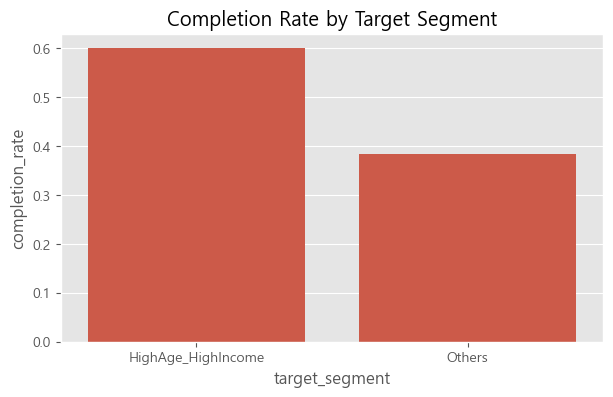

In [27]:
plt.figure(figsize=(7,4))
sns.barplot(data=target_summary, x='target_segment', y='completion_rate')
plt.title('Completion Rate by Target Segment')
plt.ylabel('completion_rate')
plt.show()

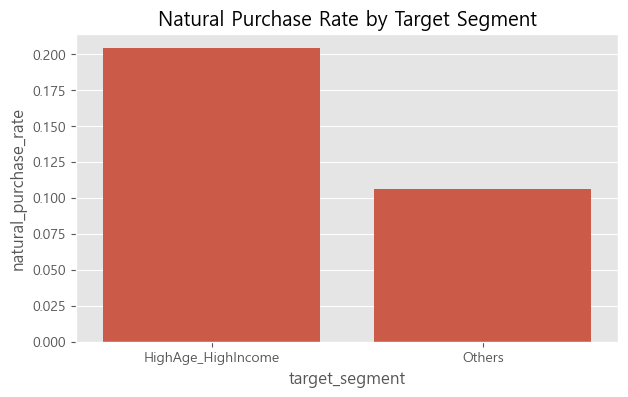

In [28]:
plt.figure(figsize=(7,4))
sns.barplot(data=target_summary, x='target_segment', y='natural_purchase_rate')
plt.title('Natural Purchase Rate by Target Segment')
plt.ylabel('natural_purchase_rate')
plt.show()

In [29]:
grp = base_df.groupby('target_segment')['is_completed'].agg(['sum', 'count'])
grp

,sum,count
target_segment,,
HighAge_HighIncome,10645,17740
Others,22456,58537


In [30]:
count = grp['sum'].values
nobs = grp['count'].values

stat, pval = proportions_ztest(count=count, nobs=nobs)
print('z-stat:', stat)
print('p-value:', pval)

z-stat: 50.95374221241875
p-value: 0.0


>p-value < 0.05 이면
고연령·고소득 세그먼트와 나머지 세그먼트의 완료율 차이가 통계적으로 유의하다.

## 가설 2 검증: 고객은 오퍼 반응형 / 자연 구매형으로 나뉘는가

In [31]:
type_summary = base_df['customer_type'].value_counts(normalize=True).reset_index()
type_summary.columns = ['customer_type', 'ratio']
type_summary

,customer_type,ratio
0,Not_Completed,0.566042
1,Offer_Responsive,0.305033
2,Natural_Purchase,0.128925


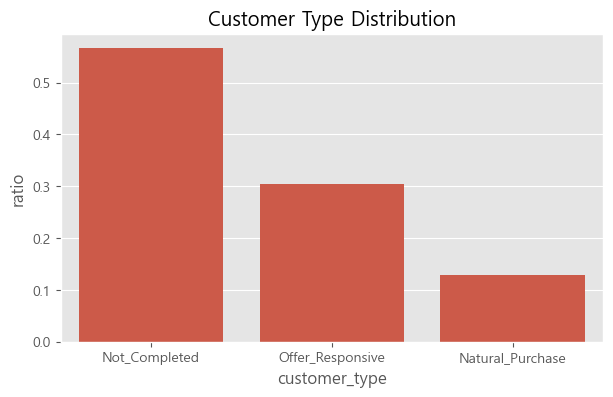

In [32]:
plt.figure(figsize=(7,4))
sns.barplot(data=type_summary, x='customer_type', y='ratio')
plt.title('Customer Type Distribution')
plt.ylabel('ratio')
plt.show()

In [33]:
type_by_target = pd.crosstab(
    base_df['target_segment'],
    base_df['customer_type'],
    normalize='index'
)

type_by_target

customer_type,Natural_Purchase,Not_Completed,Offer_Responsive
target_segment,,,
HighAge_HighIncome,0.203890,0.399944,0.396167
Others,0.106206,0.616379,0.277414


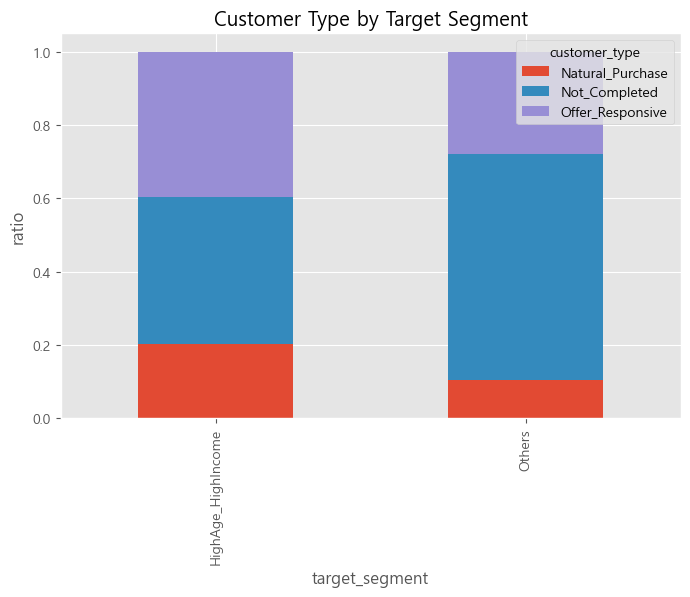

In [34]:
type_by_target.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Customer Type by Target Segment')
plt.ylabel('ratio')
plt.show()

In [35]:
cont_table = pd.crosstab(base_df['target_segment'], base_df['customer_type'])
cont_table

customer_type,Natural_Purchase,Not_Completed,Offer_Responsive
target_segment,,,
HighAge_HighIncome,3617,7095,7028
Others,6217,36081,16239


In [36]:
chi2, pval, dof, expected = chi2_contingency(cont_table)
print('chi2:', chi2)
print('p-value:', pval)
print('dof:', dof)

chi2: 2763.6943398629396
p-value: 0.0
dof: 2


> p-value < 0.05 이면 타겟 세그먼트에 따라 고객 유형 분포가 다르다.

## 가설 3 검증: 자연 구매형에는 할인 대신 다른 전략이 필요한가

In [37]:
completed_only = base_df[base_df['is_completed'] == 1].copy()

strategy_summary = completed_only.groupby('customer_type').agg(
    n=('customer_id', 'count'),
    high_age_ratio=('is_high_age', 'mean'),
    high_income_ratio=('is_high_income', 'mean'),
    avg_reward_ratio=('reward_ratio', 'mean'),
    avg_offer_strength=('offer_strength', 'mean')
).reset_index()

strategy_summary

,customer_type,n,high_age_ratio,high_income_ratio,avg_reward_ratio,avg_offer_strength
0,Natural_Purchase,9834,0.682327,0.404922,0.598718,-5.416616
1,Offer_Responsive,23267,0.639532,0.357244,0.621697,-3.881721


In [38]:
natural_by_seg = completed_only.pivot_table(
    index=['age_group', 'gender'],
    columns='customer_type',
    values='customer_id',
    aggfunc='count',
    fill_value=0
)

natural_by_seg['natural_share_among_completed'] = (
    natural_by_seg.get('Natural_Purchase', 0) /
    (natural_by_seg.get('Natural_Purchase', 0) + natural_by_seg.get('Offer_Responsive', 0))
)

natural_by_seg.sort_values('natural_share_among_completed', ascending=False).head(15)

,customer_type,Natural_Purchase,Offer_Responsive,natural_share_among_completed
age_group,gender,,,
20대 미만,F,36,47,0.433735
20대,F,342,574,0.373362
50대,F,1343,2706,0.331687
60대 이상,F,2289,4773,0.324129
20대 미만,M,75,157,0.323276
20대,M,442,966,0.313920
30대,F,369,821,0.310084
60대 이상,M,1848,4335,0.298884
50대,M,1157,2821,0.290850


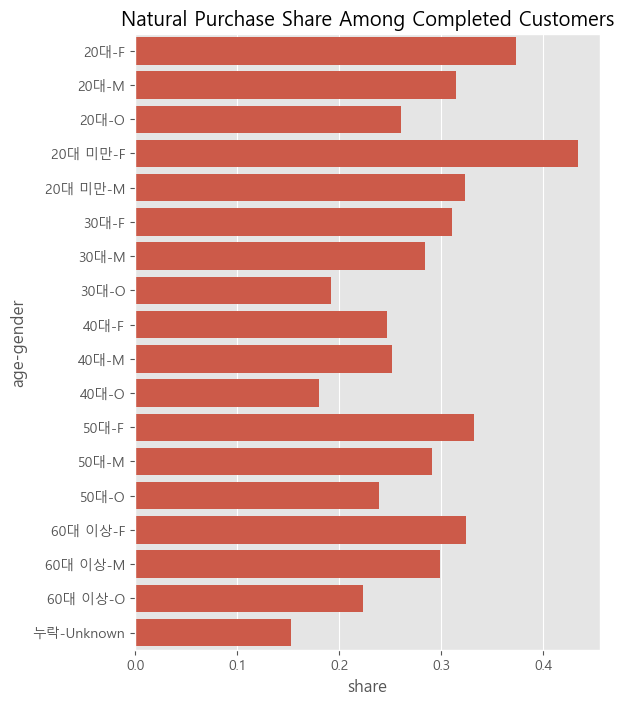

In [39]:
natural_heat = natural_by_seg[['natural_share_among_completed']].reset_index()
natural_heat['age_gender'] = natural_heat['age_group'] + '-' + natural_heat['gender']

natural_heat = natural_heat.sort_values(['age_group', 'gender'])

plt.figure(figsize=(6,8))
sns.barplot(data=natural_heat, y='age_gender', x='natural_share_among_completed')
plt.title('Natural Purchase Share Among Completed Customers')
plt.xlabel('share')
plt.ylabel('age-gender')
plt.show()

In [40]:
offer_mix = pd.crosstab(
    completed_only['customer_type'],
    completed_only['offer_type'],
    normalize='index'
)

offer_mix

offer_type,bogo,discount
customer_type,,
Natural_Purchase,0.463697,0.536303
Offer_Responsive,0.470237,0.529763


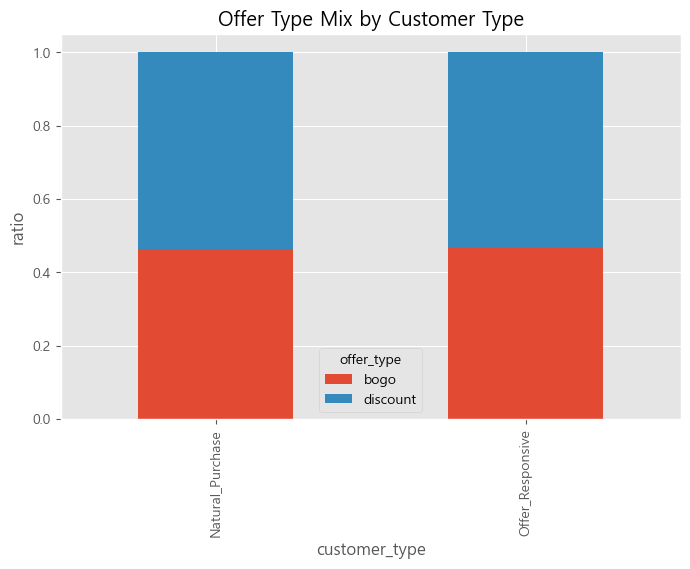

In [41]:
offer_mix.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Offer Type Mix by Customer Type')
plt.ylabel('ratio')
plt.show()

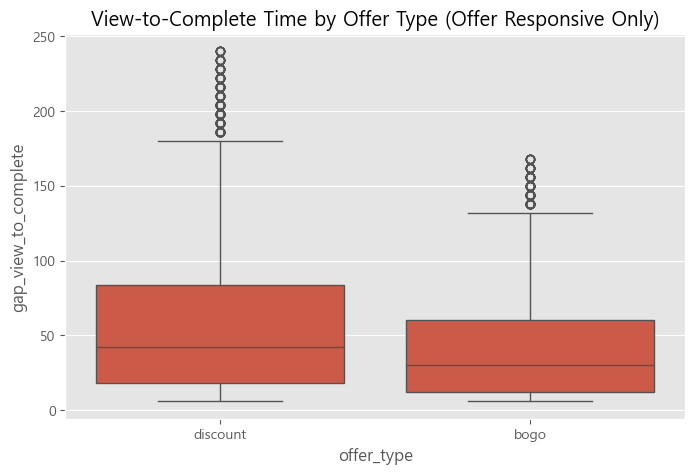

In [42]:
responsive_only = base_df[
    (base_df['customer_type'] == 'Offer_Responsive') &
    (base_df['gap_view_to_complete'].notna())
].copy()

plt.figure(figsize=(8,5))
sns.boxplot(data=responsive_only, x='offer_type', y='gap_view_to_complete')
plt.title('View-to-Complete Time by Offer Type (Offer Responsive Only)')
plt.show()

In [43]:
x = responsive_only.loc[responsive_only['offer_type'] == 'bogo', 'gap_view_to_complete']
y = responsive_only.loc[responsive_only['offer_type'] == 'discount', 'gap_view_to_complete']

stat, pval = mannwhitneyu(x, y, alternative='two-sided')
print('Mann-Whitney U:', stat)
print('p-value:', pval)

Mann-Whitney U: 42782219.0
p-value: 8.752133481182945e-115


>p-value < 0.05 이면
BOGO와 Discount는 오퍼를 본 뒤 행동 속도에서 유의한 차이가 있다.

In [44]:
final_insight_table = base_df.groupby(['target_segment', 'customer_type']).agg(
    n=('customer_id', 'count'),
    viewed_rate=('is_viewed', 'mean'),
    completion_rate=('is_completed', 'mean'),
    avg_reward_ratio=('reward_ratio', 'mean')
).reset_index()

final_insight_table

,target_segment,customer_type,n,viewed_rate,completion_rate,avg_reward_ratio
0,HighAge_HighIncome,Natural_Purchase,3617,0.393143,1.0,0.587417
1,HighAge_HighIncome,Not_Completed,7095,0.626075,0.0,0.327148
2,HighAge_HighIncome,Offer_Responsive,7028,1.000000,1.0,0.641904
3,Others,Natural_Purchase,6217,0.431559,1.0,0.605293
4,Others,Not_Completed,36081,0.686040,0.0,0.445240
5,Others,Offer_Responsive,16239,1.000000,1.0,0.612952
